# 01 — Stock Data Exploration

Phase 1 of the Indian Equity AI project plan.

Steps:
1. Download RELIANCE historical data
2. Load into Pandas, inspect
3. Clean
4. Calculate daily returns and rolling volatility
5. Plot price
6. Save cleaned dataset
7. Repeat for the full 5-stock universe

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import matplotlib.pyplot as plt
import pandas as pd

from src.ingestion.market_data import download_daily_ohlcv, download_universe
from src.preprocessing.clean import clean_ohlcv, validate_ohlcv
from src.features.returns import add_returns, add_rolling_volatility

DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
DATA_PROCESSED.mkdir(parents=True, exist_ok=True)

Matplotlib is building the font cache; this may take a moment.


## Step 1-2: Download RELIANCE and inspect

In [2]:
reliance_raw = download_daily_ohlcv("RELIANCE", period="5y")
print(reliance_raw.shape)
reliance_raw.head()

(1241, 8)


,date,symbol,open,high,low,close,adjusted_close,volume
0,2021-09-27,RELIANCE,1147.750122,1167.548462,1142.350586,1165.033203,1143.368530,15373834
1,2021-09-28,RELIANCE,1169.440552,1183.700928,1159.656738,1175.924683,1154.057495,18035258
2,2021-09-29,RELIANCE,1186.054565,1186.054565,1163.002686,1166.602417,1144.908569,9719875
3,2021-09-30,RELIANCE,1165.287109,1169.717529,1153.911133,1162.633423,1141.013306,13590654
4,2021-10-01,RELIANCE,1154.649536,1172.117310,1151.442139,1164.687134,1143.028931,8958928


In [3]:
reliance_raw.info()
reliance_raw.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1241 entries, 0 to 1240
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   date            1241 non-null   datetime64[ns]
 1   symbol          1241 non-null   object        
 2   open            1241 non-null   float64       
 3   high            1241 non-null   float64       
 4   low             1241 non-null   float64       
 5   close           1241 non-null   float64       
 6   adjusted_close  1241 non-null   float64       
 7   volume          1241 non-null   int64         
dtypes: datetime64[ns](1), float64(5), int64(1), object(1)
memory usage: 77.7+ KB


,date,open,high,low,close,adjusted_close,volume
count,1241,1241.000000,1241.000000,1241.000000,1241.000000,1241.000000,1.241000e+03
mean,2024-03-29 10:52:07.155519488,1289.033805,1300.455479,1277.258285,1288.444972,1274.485859,1.321902e+07
min,2021-09-27 00:00:00,1020.606873,1024.529663,1006.069641,1015.876526,1000.238525,0.000000e+00
25%,2022-12-26 00:00:00,1172.048096,1183.000000,1162.800049,1172.525024,1155.719116,8.818766e+06
50%,2024-04-01 00:00:00,1269.949951,1282.400024,1257.824951,1269.000000,1256.746826,1.172005e+07
75%,2025-07-02 00:00:00,1414.000000,1425.699951,1399.099976,1412.800049,1401.647217,1.592577e+07
max,2026-09-25 00:00:00,1604.449951,1611.800049,1585.500000,1600.900024,1584.971802,8.199715e+07
std,NaN,139.985420,140.617905,139.469915,139.979727,142.622134,6.788194e+06


## Step 3: Validate and clean

In [4]:
print("Issues before cleaning:", validate_ohlcv(reliance_raw))
reliance = clean_ohlcv(reliance_raw)
print("Issues after cleaning:", validate_ohlcv(reliance))
print("Rows kept:", len(reliance), "/", len(reliance_raw))

Issues before cleaning: {'missing_values': 0, 'duplicate_rows': 0, 'non_positive_prices': 0, 'negative_volume': 0, 'high_below_low': 0}
Issues after cleaning: {'missing_values': 0, 'duplicate_rows': 0, 'non_positive_prices': 0, 'negative_volume': 0, 'high_below_low': 0}
Rows kept: 1241 / 1241


## Step 4: Returns and rolling volatility

In [5]:
reliance = add_returns(reliance)
reliance = add_rolling_volatility(reliance)
reliance[["date", "close", "return_1d", "return_20d", "volatility_20d"]].tail()

,date,close,return_1d,return_20d,volatility_20d
1236,2026-09-21,1247.400024,0.017123,-0.047641,0.011810
1237,2026-09-22,1240.400024,-0.005612,-0.058162,0.011681
1238,2026-09-23,1248.000000,0.006127,-0.038521,0.011519
1239,2026-09-24,1219.199951,-0.023077,-0.049134,0.012265
1240,2026-09-25,1226.000000,0.005577,-0.047397,0.012320


## Step 5: Plot price

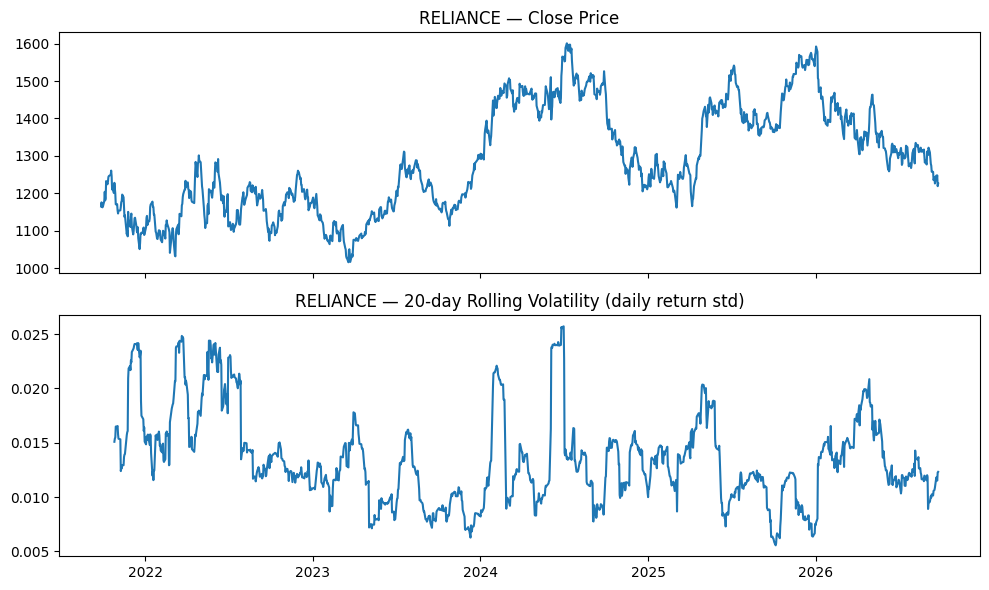

In [6]:
fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
axes[0].plot(reliance["date"], reliance["close"])
axes[0].set_title("RELIANCE — Close Price")
axes[1].plot(reliance["date"], reliance["volatility_20d"])
axes[1].set_title("RELIANCE — 20-day Rolling Volatility (daily return std)")
plt.tight_layout()
plt.show()

## Step 6: Save cleaned single-stock dataset

In [7]:
reliance.to_parquet(DATA_PROCESSED / "RELIANCE.parquet", index=False)
print("Saved:", DATA_PROCESSED / "RELIANCE.parquet")

Saved: D:\Practise\Stock Market Analysis\data\processed\RELIANCE.parquet


## Step 7: Expand to the full 5-stock universe

In [8]:
UNIVERSE = ["RELIANCE", "TCS", "INFY", "HDFCBANK", "ITC"]

universe_raw = download_universe(UNIVERSE, period="5y")
print("Raw issues:", validate_ohlcv(universe_raw))

universe = clean_ohlcv(universe_raw)
universe = add_returns(universe)
universe = add_rolling_volatility(universe)

print("Post-clean issues:", validate_ohlcv(universe))
universe.groupby("symbol")["date"].agg(["min", "max", "count"])

Raw issues: {'missing_values': 0, 'duplicate_rows': 0, 'non_positive_prices': 0, 'negative_volume': 0, 'high_below_low': 0}
Post-clean issues: {'missing_values': 0, 'duplicate_rows': 0, 'non_positive_prices': 0, 'negative_volume': 0, 'high_below_low': 0}


,min,max,count
symbol,,,
HDFCBANK,2021-09-27,2026-09-25,1241
INFY,2021-09-27,2026-09-25,1241
ITC,2021-09-27,2026-09-25,1241
RELIANCE,2021-09-27,2026-09-25,1241
TCS,2021-09-27,2026-09-25,1241


In [9]:
assert validate_ohlcv(universe) == {
    "missing_values": 0,
    "duplicate_rows": 0,
    "non_positive_prices": 0,
    "negative_volume": 0,
    "high_below_low": 0,
}, "Cleaned universe dataset still has data-quality issues"

for symbol in UNIVERSE:
    subset = universe[universe["symbol"] == symbol]
    subset.to_parquet(DATA_PROCESSED / f"{symbol}.parquet", index=False)

universe.to_parquet(DATA_PROCESSED / "prices_daily.parquet", index=False)
print("Saved per-symbol files and combined prices_daily.parquet for:", UNIVERSE)

Saved per-symbol files and combined prices_daily.parquet for: ['RELIANCE', 'TCS', 'INFY', 'HDFCBANK', 'ITC']


## Sanity check: plot all 5 closing prices (normalized to 100 at start)

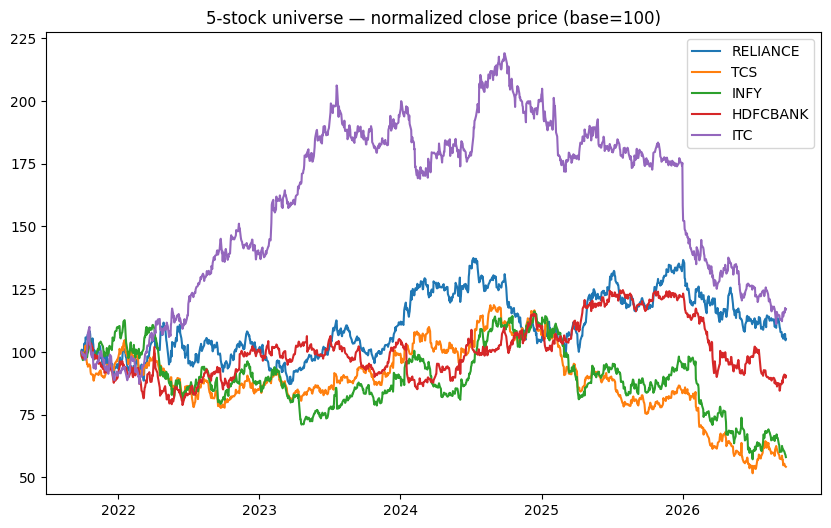

In [10]:
plt.figure(figsize=(10, 6))
for symbol in UNIVERSE:
    subset = universe[universe["symbol"] == symbol].sort_values("date")
    normalized = subset["close"] / subset["close"].iloc[0] * 100
    plt.plot(subset["date"], normalized, label=symbol)
plt.legend()
plt.title("5-stock universe — normalized close price (base=100)")
plt.show()